# 📈 Retail Sales Forecasting: Time Series Analysis
**Level:** Advanced · **Tools:** Python, Pandas, Statsmodels (Holt-Winters, SARIMA), Scikit-learn

**Business problem:** the operations team at a UK online retailer needs a **30-day revenue forecast** to plan stock and staffing ahead of the holiday season.

**Data:** daily revenue built from the [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail) transactions (Dec 2010 – Dec 2011, cancellations removed). The store **doesn't trade on Saturdays**, so the series is modelled on **trading days** with a 6-day weekly cycle.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
warnings.filterwarnings("ignore"); sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110
df = pd.read_csv("data/daily_sales.csv", parse_dates=["Date"]).set_index("Date")
print(df.shape); df.describe().round(0)

(305, 3)


,Revenue,Orders,Customers
count,305.0,305.0,305.0
mean,34973.0,65.0,55.0
std,21117.0,25.0,21.0
min,3457.0,11.0,11.0
25%,22353.0,49.0,41.0
50%,29651.0,63.0,52.0
75%,45390.0,77.0,65.0
max,200921.0,142.0,125.0


## 1. Exploration

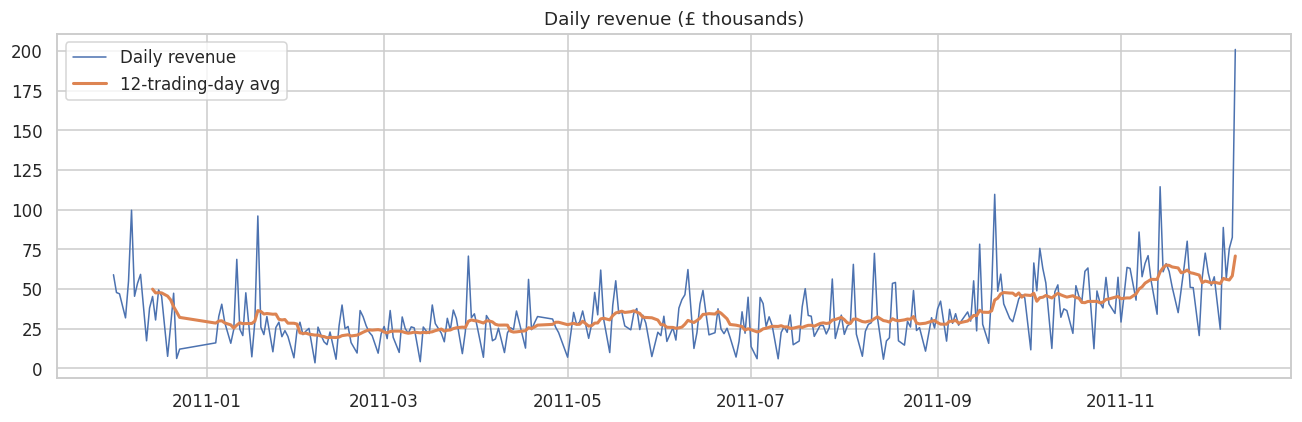

Largest day: 2011-12-09 £200,921


In [2]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(df.index, df.Revenue/1e3, lw=1, label="Daily revenue"); ax.plot(df.index, df.Revenue.rolling(12).mean()/1e3, lw=2, label="12-trading-day avg")
ax.set_title("Daily revenue (£ thousands)"); ax.legend(); plt.tight_layout(); plt.savefig("images/daily_revenue.png", bbox_inches="tight"); plt.show()
print("Largest day:", df.Revenue.idxmax().date(), f"£{df.Revenue.max():,.0f}")

**Outlier:** 9 Dec 2011 is inflated by one 80,995-unit order (£168K) that the customer cancelled straight away. The cleaning step removed the cancellation line but kept the original order. Revenue is capped at the 99th percentile so this data error doesn't distort the models.

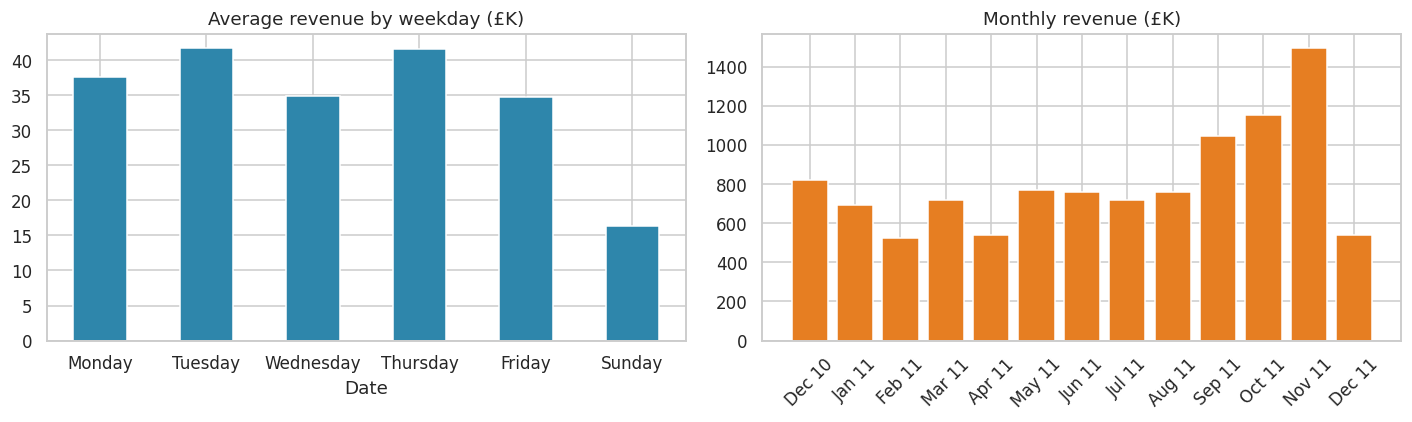

In [3]:
cap = df.Revenue.quantile(0.99); df["RevenueClean"] = df.Revenue.clip(upper=cap)
dow = df.groupby(df.index.day_name()).RevenueClean.mean().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Sunday"])
mon = df.RevenueClean.resample("MS").sum()
fig, ax = plt.subplots(1,2, figsize=(13,4))
(dow/1e3).plot.bar(ax=ax[0], color="#2E86AB", title="Average revenue by weekday (£K)", rot=0)
ax[1].bar([d.strftime("%b %y") for d in mon.index], mon.values/1e3, color="#E67E22"); ax[1].set_title("Monthly revenue (£K)"); ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.savefig("images/weekday_monthly.png", bbox_inches="tight"); plt.show()

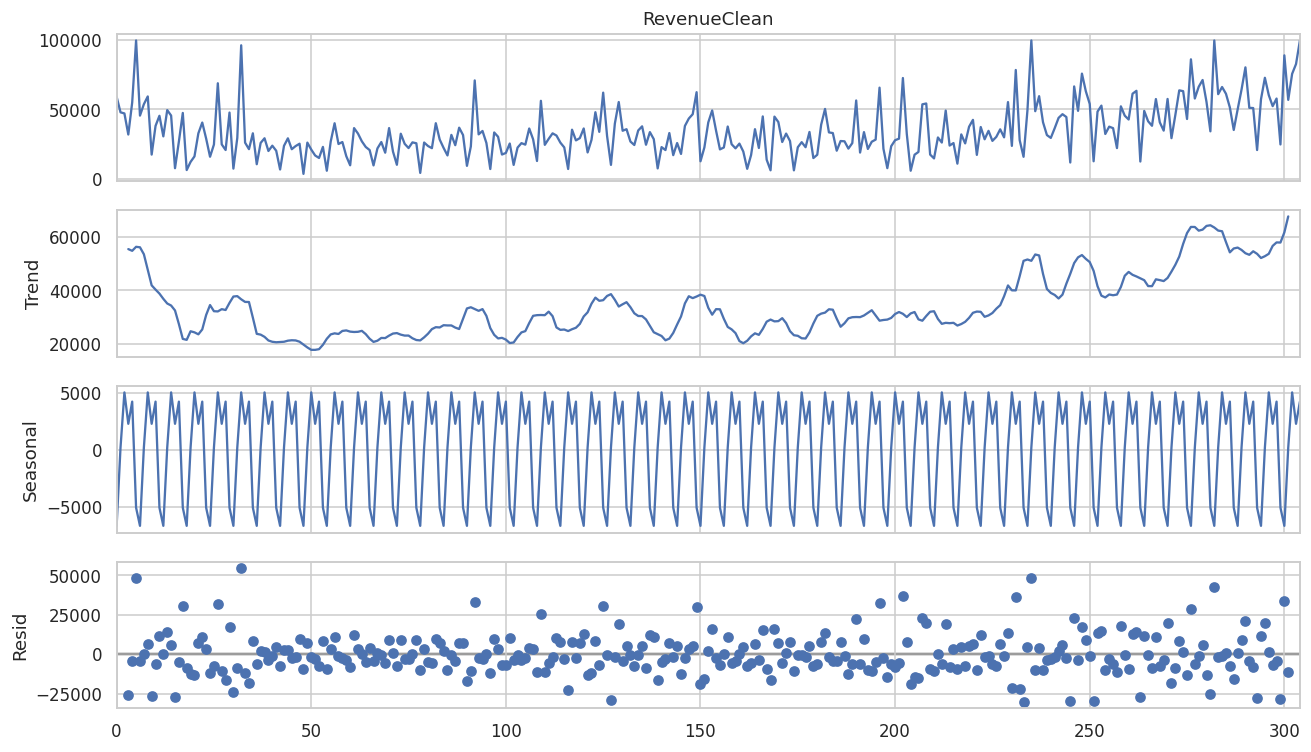

ADF p-value: 0.8246 → non-stationary (trend present)


In [4]:
y = df.RevenueClean.reset_index(drop=True)   # trading-day index
dec = seasonal_decompose(y, period=6, model="additive")
fig = dec.plot(); fig.set_size_inches(12,7); plt.tight_layout(); plt.savefig("images/decomposition.png", bbox_inches="tight"); plt.show()
adf = adfuller(y); print(f"ADF p-value: {adf[1]:.4f} → {'stationary' if adf[1]<0.05 else 'non-stationary (trend present)'}")

## 2. Train/test split
The last **30 trading days** (≈5 weeks, mid-Nov to Dec) are held out, which is the peak season the business cares about.

In [5]:
H = 30; train, test = y[:-H], y[-H:]; dates_test = df.index[-H:]
def score(name, pred): return {"Model": name, "MAE (£)": mean_absolute_error(test, pred), "MAPE %": mean_absolute_percentage_error(test, pred)*100}
preds, scores = {}, []
# Baseline 1: seasonal naive (same weekday last week)
preds["Seasonal Naive"] = np.tile(train.values[-6:], H//6+1)[:H]
# Baseline 2: moving average of last 4 weeks
preds["Moving Average (24d)"] = np.repeat(train[-24:].mean(), H)
# Holt-Winters: additive trend (damped) + 6-day seasonality
hw = ExponentialSmoothing(train, trend="add", damped_trend=True, seasonal="add", seasonal_periods=6).fit()
preds["Holt-Winters"] = hw.forecast(H).values
# SARIMA
sar = SARIMAX(train, order=(1,1,1), seasonal_order=(1,0,1,6)).fit(disp=False)
preds["SARIMA(1,1,1)(1,0,1,6)"] = sar.forecast(H).values
print("done")

done


In [6]:
# Machine-learning approach: gradient boosting on lag + calendar features (recursive forecasting)
feat = pd.DataFrame({"y": y.values}, index=df.index)
def make_features(s, idx):
    X = pd.DataFrame(index=idx)
    for l in [1,2,3,6,12,18]: X[f"lag_{l}"] = s.shift(l)
    X["roll_6"] = s.shift(1).rolling(6).mean(); X["roll_24"] = s.shift(1).rolling(24).mean()
    X["dow"] = idx.dayofweek; X["month"] = idx.month; X["t"] = np.arange(len(idx))
    return X
X_all = make_features(feat.y, feat.index)
tr_mask = np.arange(len(feat)) < len(feat)-H
gbr = GradientBoostingRegressor(n_estimators=400, max_depth=3, learning_rate=0.03, random_state=42)
gbr.fit(X_all[tr_mask].dropna(), feat.y[tr_mask][X_all[tr_mask].notna().all(axis=1)])
hist = feat.y.copy(); hist.iloc[-H:] = np.nan; out=[]
for i in range(len(feat)-H, len(feat)):
    Xi = make_features(hist, feat.index).iloc[[i]]
    p = gbr.predict(Xi)[0]; hist.iloc[i] = p; out.append(p)
preds["Gradient Boosting (lags)"] = np.array(out)
res = pd.DataFrame([score(k,v) for k,v in preds.items()]).set_index("Model").round(1).sort_values("MAPE %"); res

,MAE (£),MAPE %
Model,,
Holt-Winters,17513.7,25.7
"SARIMA(1,1,1)(1,0,1,6)",17014.3,26.7
Gradient Boosting (lags),17469.0,27.2
Seasonal Naive,18454.9,29.3
Moving Average (24d),21704.8,35.0


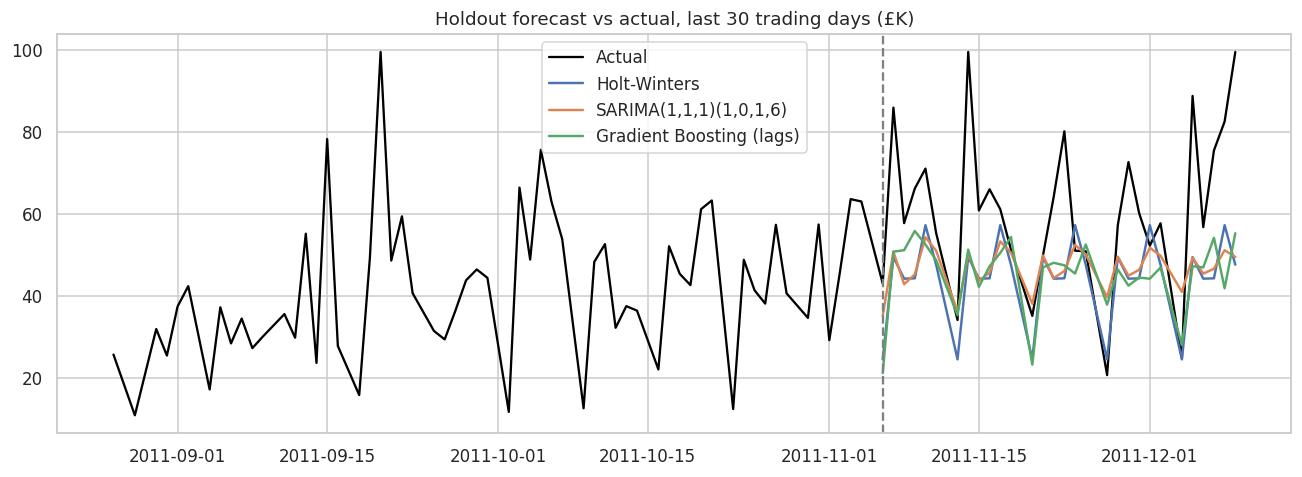

In [7]:
fig, ax = plt.subplots(figsize=(12,4.5))
ax.plot(df.index[-90:], y[-90:]/1e3, color="black", lw=1.5, label="Actual")
for name in res.index[:3]: ax.plot(dates_test, preds[name]/1e3, lw=1.6, label=name)
ax.axvline(dates_test[0], color="grey", ls="--"); ax.set_title("Holdout forecast vs actual, last 30 trading days (£K)"); ax.legend()
plt.tight_layout(); plt.savefig("images/holdout_forecast.png", bbox_inches="tight"); plt.show()

## 3. Final 30-day forecast
The best model is refit on **all** data and used to forecast the next 30 trading days, with an 80% prediction interval from the model's residuals.

Best model on holdout: Holt-Winters


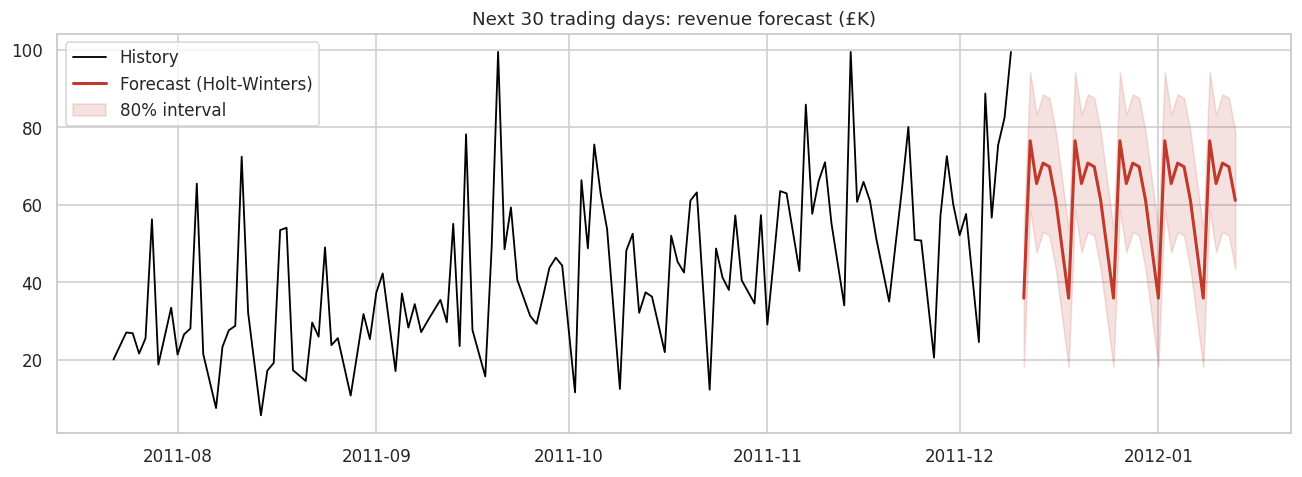

Forecast total for next 30 trading days: £1,899,154  (80% range £1,366,724 – £2,431,584)


,Date,Forecast,Lower_80,Upper_80
0,2011-12-11,35951.0,18203.0,53699.0
1,2011-12-12,76554.0,58806.0,94301.0
2,2011-12-13,65512.0,47764.0,83260.0
3,2011-12-14,70782.0,53034.0,88530.0
4,2011-12-15,69856.0,52108.0,87603.0
5,2011-12-16,61176.0,43429.0,78924.0
6,2011-12-18,35951.0,18203.0,53699.0
7,2011-12-19,76554.0,58806.0,94301.0
8,2011-12-20,65512.0,47764.0,83260.0
9,2011-12-21,70782.0,53034.0,88530.0


In [8]:
best = res.index[0]; print("Best model on holdout:", best)
if best.startswith("SARIMA"):
    m = SARIMAX(y, order=(1,1,1), seasonal_order=(1,0,1,6)).fit(disp=False); fc = m.get_forecast(H)
    mean = fc.predicted_mean.values; lo, hi = fc.conf_int(alpha=0.2).values.T
else:
    m = ExponentialSmoothing(y, trend="add", damped_trend=True, seasonal="add", seasonal_periods=6).fit()
    mean = m.forecast(H).values; sd = np.std(m.resid); lo, hi = mean-1.28*sd, mean+1.28*sd
# future trading days (skip Saturdays)
fut = pd.bdate_range(df.index[-1]+pd.Timedelta(days=1), periods=60, freq="C", weekmask="Mon Tue Wed Thu Fri Sun")[:H]
fcst = pd.DataFrame({"Date": fut, "Forecast": mean.round(0), "Lower_80": np.maximum(lo,0).round(0), "Upper_80": hi.round(0)})
fcst.to_csv("output/forecast_next_30_trading_days.csv", index=False)
fig, ax = plt.subplots(figsize=(12,4.5))
ax.plot(df.index[-120:], y[-120:]/1e3, color="black", lw=1.2, label="History")
ax.plot(fut, mean/1e3, color="#C0392B", lw=2, label=f"Forecast ({best})"); ax.fill_between(fut, np.maximum(lo,0)/1e3, hi/1e3, color="#C0392B", alpha=0.15, label="80% interval")
ax.set_title("Next 30 trading days: revenue forecast (£K)"); ax.legend(); plt.tight_layout(); plt.savefig("images/future_forecast.png", bbox_inches="tight"); plt.show()
print(f"Forecast total for next 30 trading days: £{mean.sum():,.0f}  (80% range £{np.maximum(lo,0).sum():,.0f} – £{hi.sum():,.0f})")
fcst.head(10)

## 4. Takeaways
- **Strong growth into Q4:** revenue climbs sharply from September to November (the holiday gifting season). The series is non-stationary (ADF p = 0.82), so trend-aware models beat flat baselines.
- **Weekly pattern:** **Tuesday and Thursday** are the strongest trading days (~£41.6K on average) and **Sunday** the weakest (~£16.3K); Saturday has no trading.
- **Best model: Holt-Winters** (damped trend + 6-day seasonality) with a **25.7% MAPE** on the hardest 5 weeks of the year. It beats the seasonal-naive baseline (29.3%) and the moving average (35.0%). SARIMA and gradient boosting are close behind, so on a short 1-year daily series a simple, explainable model is enough.
- **Forecast:** about **£1.9M revenue over the next 30 trading days** (80% range £1.37M–£2.43M).
- **Caveat:** with only one year of history, yearly seasonality (the Christmas → January slump) can't be learned. The forecast past mid-December should be treated as an upper bound, and the model retrained once more history is available.